# Phase 7 — Du régime détecté à l'allocation expliquée

**Question de soutenance :** peut-on reconstruire une décision et expliquer ce
que les challengers RF/XGBoost ont appris, sans attribuer causalement les marchés
aux modèles ?

Le système `regime_conditional` est expliqué par une trace de décision. Les
challengers sont expliqués par attribution exacte de leur fonction prédictive.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

**Snapshot canonique :** `ae87f48207d1`  — généré le `2026-08-09T02:32:55.411586+00:00` — arbre source propre.

In [2]:
explanations = load_json("model_explanations.json")
regime = pd.read_parquet(GOLD / "dashboard_regime.parquet")
regime["Date"] = pd.to_datetime(regime["Date"])

policy = explanations["explanation_policy"]
display(pd.Series(policy, name="politique d'explication").to_frame())
assert policy["shap_package_used"] is False

,politique d'explication
causality,No explanation in this artifact supports a cau...
challenger_method,exact additive tree contributions + seeded per...
primary_method,deterministic decision trace (fits no predicti...
primary_system,regime_conditional
shap_package_used,False
shap_rationale,xgboost ships TreeSHAP natively and scikit-lea...


## Chronologie causale des régimes

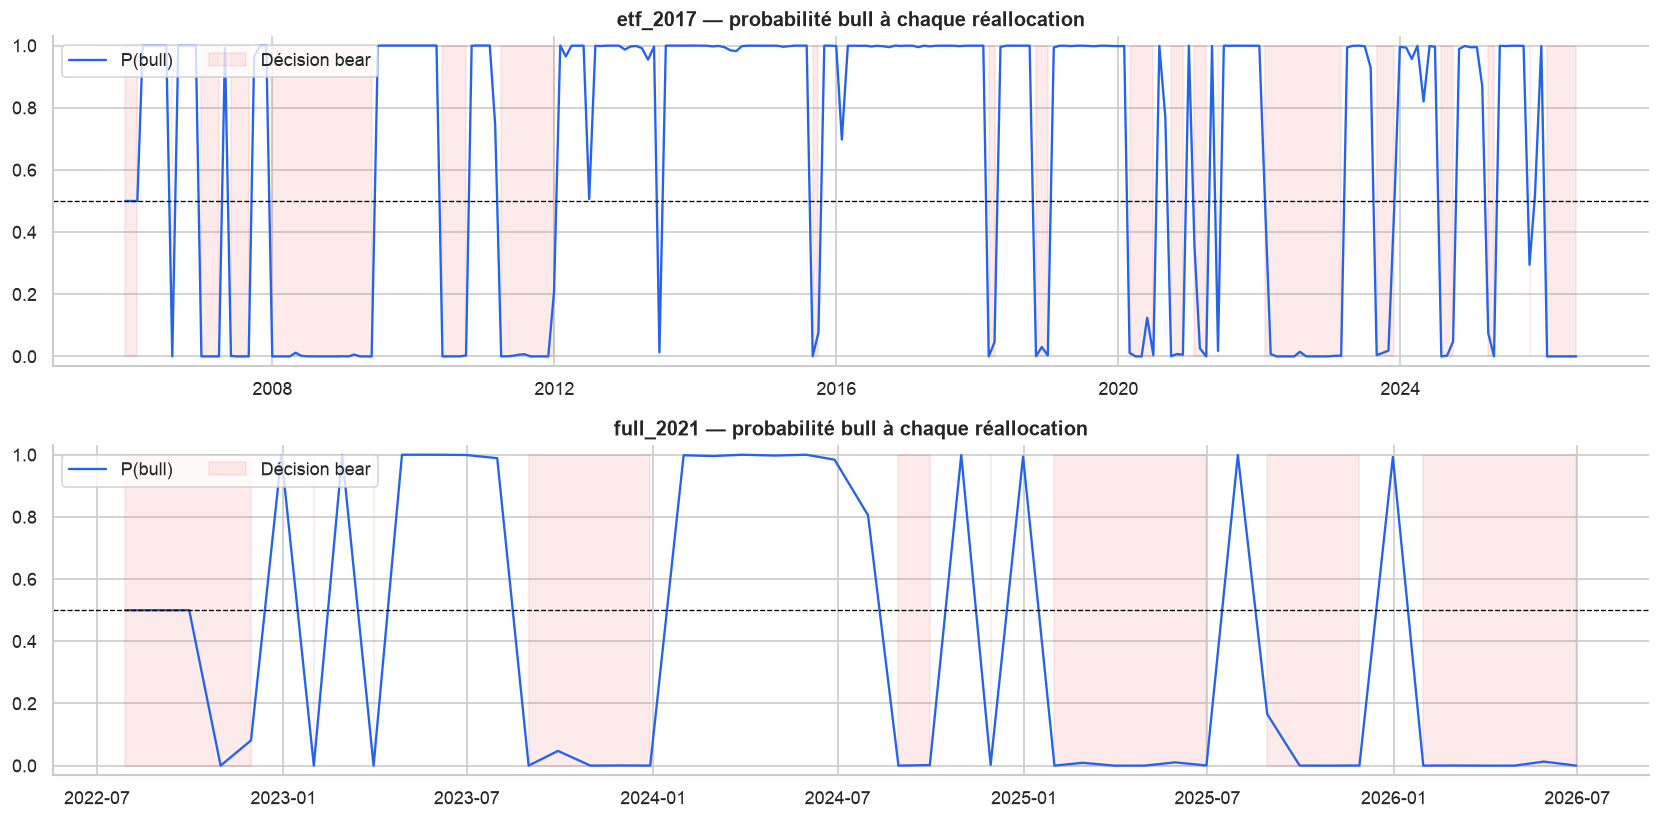

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, (universe, frame) in zip(axes, regime.groupby("universe", sort=True)):
    frame = frame.sort_values("Date")
    ax.plot(frame["Date"], frame["bull_prob"], color="#2563eb", lw=1.4, label="P(bull)")
    ax.fill_between(frame["Date"], 0, 1, where=frame["regime"].eq("bear"), color="#ef4444", alpha=0.10, label="Décision bear")
    ax.axhline(0.5, color="black", lw=0.8, ls="--")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f"{universe} — probabilité bull à chaque réallocation")
    ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

## Dernière décision reconstruite de bout en bout

,date,régime,sous-optimiseur,P(bull),P(bear),HMM convergé,fallback,positions au plafond
univers,,,,,,,,
etf_2017,2026-07-24,bear,min_variance_lw,0.0000,1.0000,True,False,4
full_2021,2026-07-24,bear,min_variance_lw,0.0019,0.9981,True,False,1


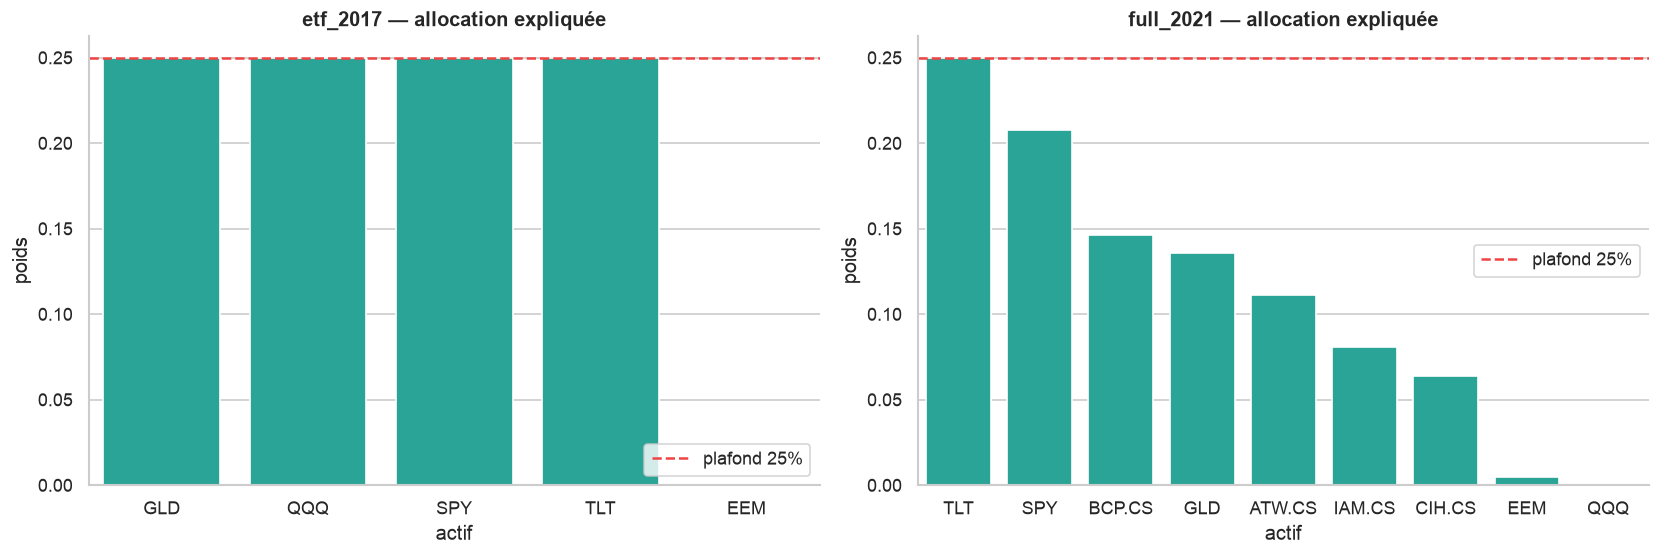

In [4]:
decision_rows = []
weight_rows = []
for universe, payload in explanations["universes"].items():
    primary = payload["primary"]
    decision_rows.append({
        "univers": universe,
        "date": primary["decision_date"],
        "régime": primary["decision"]["selected_regime"],
        "sous-optimiseur": primary["decision"]["selected_sub_optimizer"],
        "P(bull)": primary["hmm"]["posterior"]["bull"],
        "P(bear)": primary["hmm"]["posterior"]["bear"],
        "HMM convergé": primary["hmm"]["converged"],
        "fallback": primary["fallback_used"],
        "positions au plafond": primary["constraints"]["n_binding_at_cap"],
    })
    for asset, weight in primary["weights"].items():
        weight_rows.append({"univers": universe, "actif": asset, "poids": weight})

display(pd.DataFrame(decision_rows).set_index("univers").style.format({"P(bull)": "{:.4f}", "P(bear)": "{:.4f}"}))

weights = pd.DataFrame(weight_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (universe, frame) in zip(axes, weights.groupby("univers", sort=True)):
    sns.barplot(data=frame.sort_values("poids", ascending=False), x="actif", y="poids", color="#14b8a6", ax=ax)
    cap = explanations["universes"][universe]["primary"]["constraints"]["max_weight"]
    ax.axhline(cap, color="#ef4444", ls="--", label=f"plafond {cap:.0%}")
    ax.set_title(f"{universe} — allocation expliquée")
    ax.legend()
plt.tight_layout()
plt.show()

## Importance globale des challengers

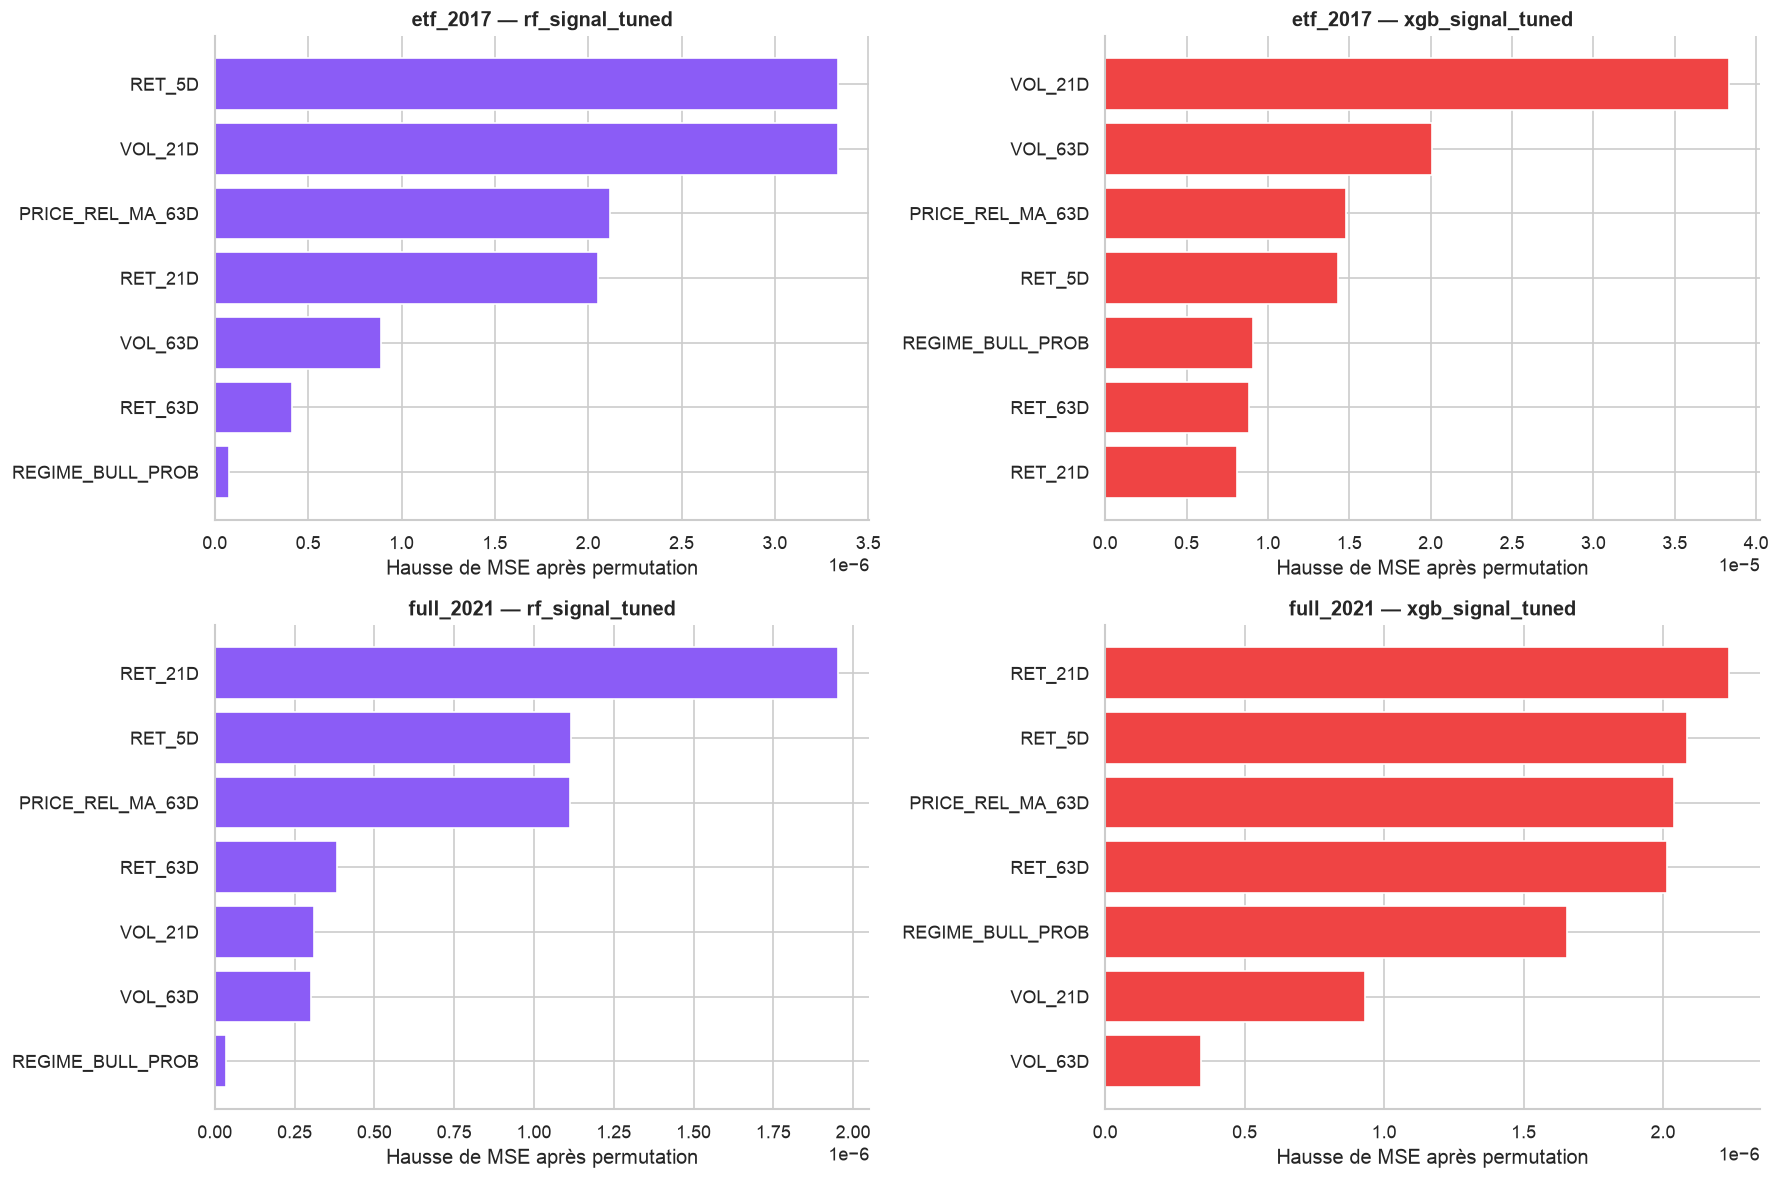

In [5]:
importance_rows = []
for universe, payload in explanations["universes"].items():
    for challenger, model in payload["challengers"].items():
        for item in model["global_importance_permutation"]:
            importance_rows.append({
                "univers": universe,
                "challenger": challenger,
                "variable": item["feature"],
                "augmentation MSE": item["mse_increase"],
                "rang": item["rank"],
            })
importance = pd.DataFrame(importance_rows)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, ((universe, challenger), frame) in zip(axes.flat, importance.groupby(["univers", "challenger"], sort=True)):
    frame = frame.sort_values("augmentation MSE")
    ax.barh(frame["variable"], frame["augmentation MSE"], color=COLORS.get(challenger, "#64748b"))
    ax.set_title(f"{universe} — {challenger}")
    ax.set_xlabel("Hausse de MSE après permutation")
plt.tight_layout()
plt.show()

## Du classement prédit aux poids réellement détenus

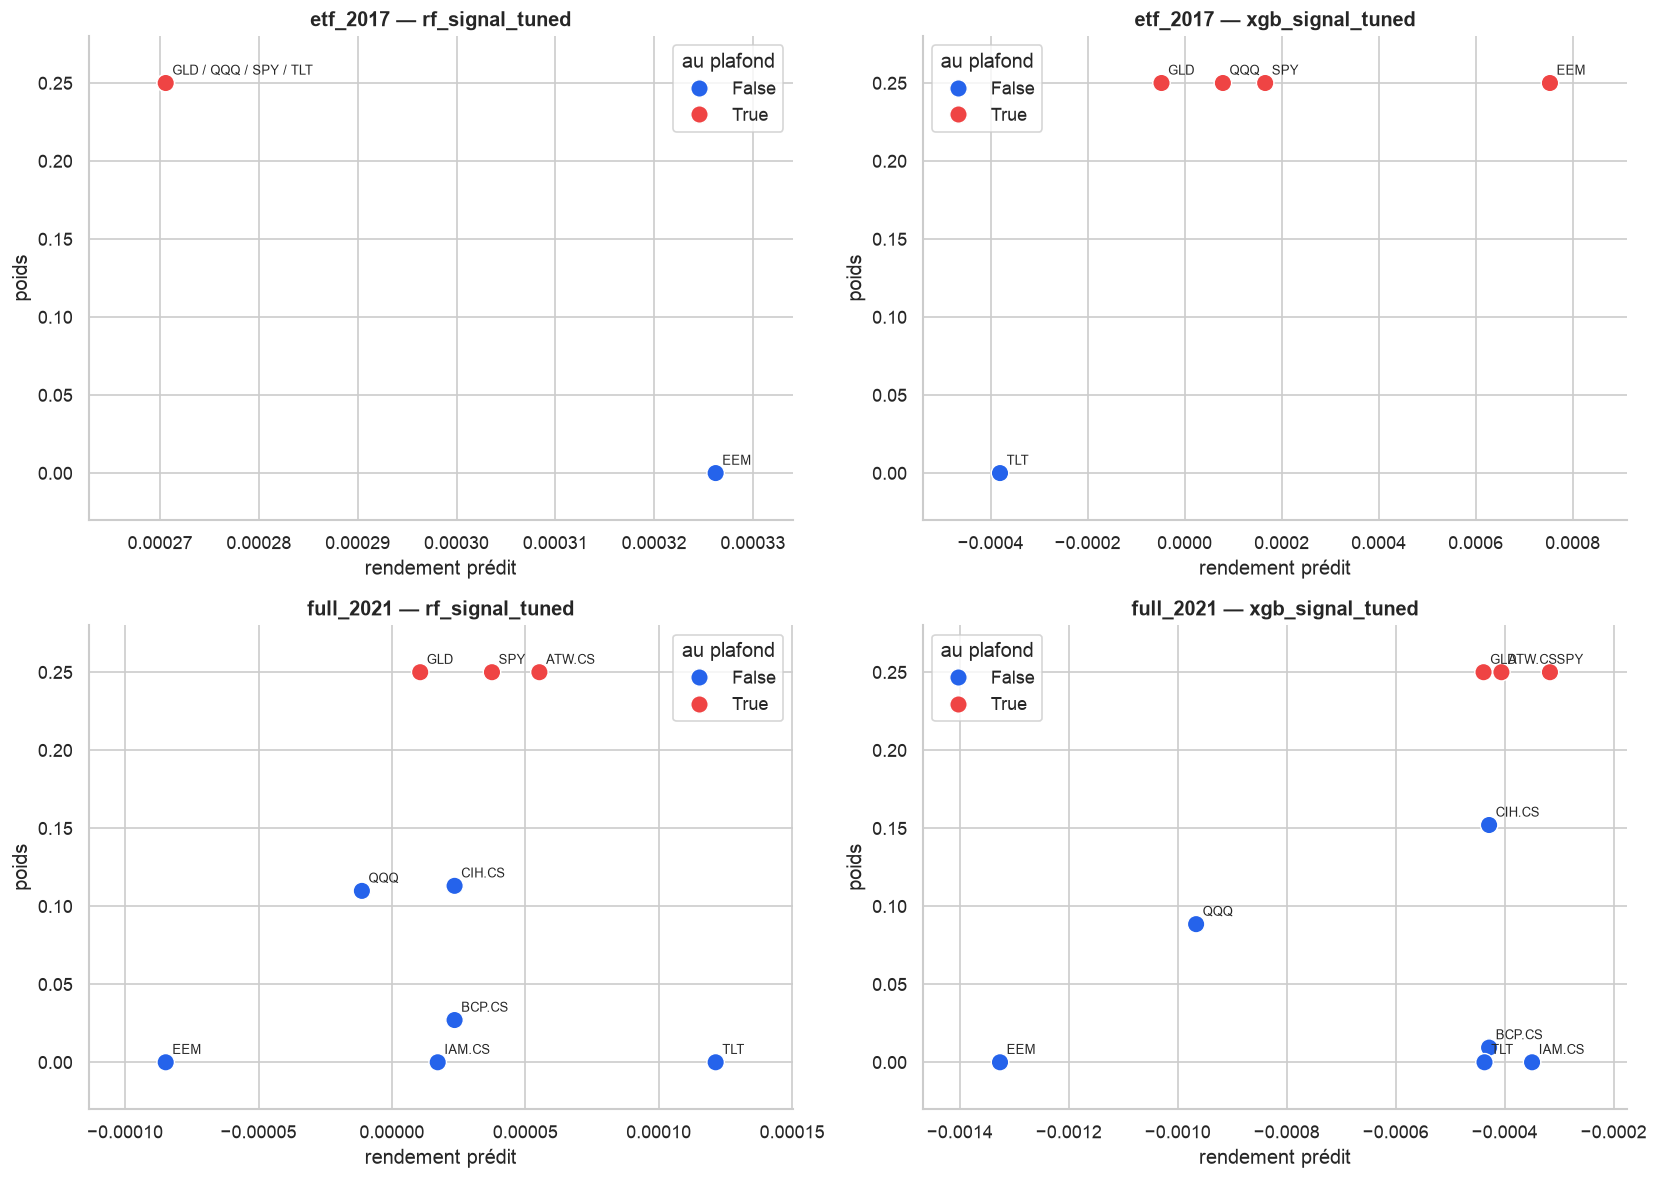

In [6]:
link_rows = []
concordance_rows = []
for universe, payload in explanations["universes"].items():
    for challenger, model in payload["challengers"].items():
        link = model["ranking_to_weights"]
        concordance_rows.append({
            "univers": universe,
            "challenger": challenger,
            "concordance de Spearman": link["rank_concordance_spearman"],
            "raison si indéfinie": link["concordance_undefined_reason"],
        })
        for asset, item in link["per_asset"].items():
            link_rows.append({
                "univers": universe,
                "challenger": challenger,
                "actif": asset,
                "rendement prédit": item["predicted_expected_return"],
                "rang prédit": item["predicted_rank"],
                "poids": item["weight"],
                "rang poids": item["weight_rank"],
                "au plafond": item["at_cap"],
            })

concordance = pd.DataFrame(concordance_rows)
display(concordance.set_index(["univers", "challenger"]).style.format({"concordance de Spearman": "{:+.3f}"}, na_rep="non définie"))

links = pd.DataFrame(link_rows)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, ((universe, challenger), frame) in zip(axes.flat, links.groupby(["univers", "challenger"], sort=True)):
    sns.scatterplot(data=frame, x="rendement prédit", y="poids", hue="au plafond", s=110, ax=ax, palette={True: "#ef4444", False: "#2563eb"})
    labels = (
        frame.assign(
            x_label=frame["rendement prédit"].round(10),
            y_label=frame["poids"].round(6),
        )
        .groupby(["x_label", "y_label"], as_index=False)["actif"]
        .agg(" / ".join)
    )
    for row in labels.itertuples(index=False):
        ax.annotate(row.actif, (row.x_label, row.y_label), xytext=(4, 5), textcoords="offset points", fontsize=8)
    ax.margins(x=0.14, y=0.12)
    ax.set_title(f"{universe} — {challenger}")
plt.tight_layout()
plt.show()

## Attribution locale exacte — le cas le plus contradictoire

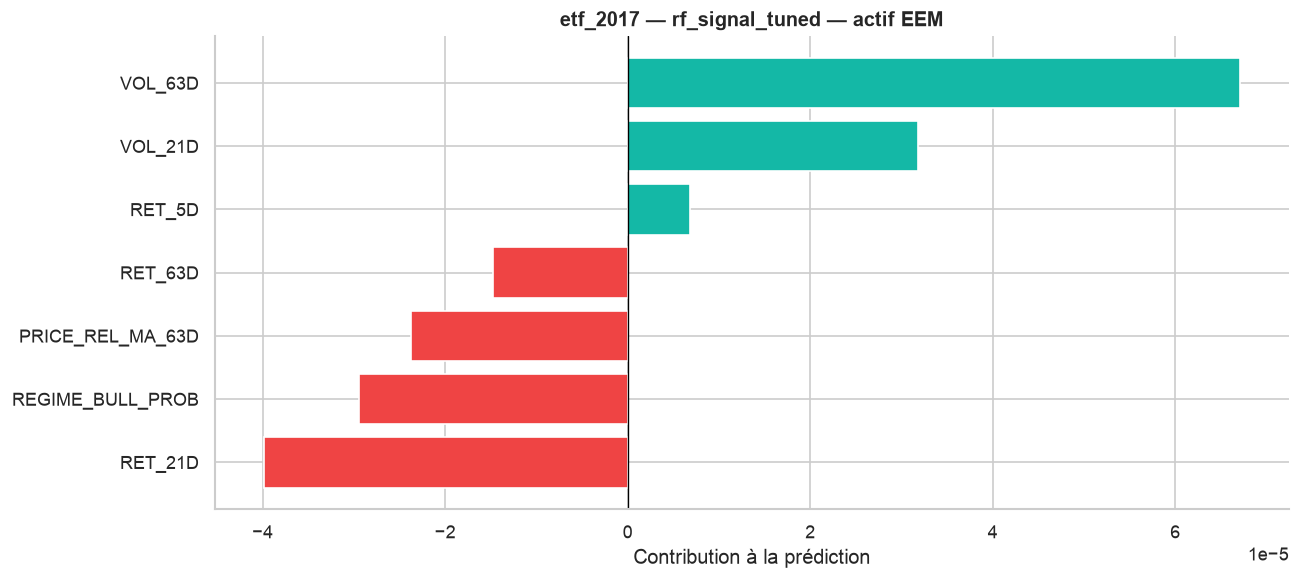


**Reconstruction :** biais `0.00032824` + contributions = prédiction `0.00032623`.  
Erreur de reconstruction : `1.626e-19` — méthode : decision-path decomposition (exact, Saabas).

La concordance classement→poids de ce cas vaut **-1.000**.
Ce nombre ne prouve pas un défaut du modèle : le poids final combine rendement prédit,
covariance et contraintes. Il montre précisément pourquoi une attribution prédictive ne suffit
pas à expliquer une allocation.


In [7]:
finite = concordance.dropna(subset=["concordance de Spearman"])
case = finite.loc[finite["concordance de Spearman"].idxmin()]
model = explanations["universes"][case["univers"]]["challengers"][case["challenger"]]
local = model["local_contributions"]
contrib = pd.Series(local["contributions"]).sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
colors = np.where(contrib >= 0, "#14b8a6", "#ef4444")
ax.barh(contrib.index, contrib.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"{case['univers']} — {case['challenger']} — actif {local['asset']}")
ax.set_xlabel("Contribution à la prédiction")
plt.tight_layout()
plt.show()

display(Markdown(f"""
**Reconstruction :** biais `{local['bias']:.8f}` + contributions = prédiction `{local['prediction']:.8f}`.  
Erreur de reconstruction : `{local['reconstruction_error']:.3e}` — méthode : {local['method']}.

La concordance classement→poids de ce cas vaut **{case['concordance de Spearman']:+.3f}**.
Ce nombre ne prouve pas un défaut du modèle : le poids final combine rendement prédit,
covariance et contraintes. Il montre précisément pourquoi une attribution prédictive ne suffit
pas à expliquer une allocation.
"""))

### Ce que ce notebook établit

- La décision HMM → sous-optimiseur → poids est reconstructible à une date donnée.
- Les attributions RF/XGBoost sont additives et décrivent la fonction ajustée.
- La contrainte de 25 % peut dominer le passage du classement prédit aux poids.

### Ce qu'il n'établit pas

- Une contribution de variable n'est pas une cause économique.
- Une décision expliquée n'est ni une recommandation ni une validation du modèle.